In [6]:
# ============================================================
# NOTEBOOK 02 — QSAR MODEL BUILDING
# PfDHFR Inhibitor Discovery from African Natural Products
# ============================================================
# Tracks:
#   A — Binary classification (active vs inactive, pIC50 >= 6.0)
#   B — Regression (predict pIC50 value)
# Models per track: Random Forest, XGBoost, SVM, Stacking Ensemble
# Extras: SHAP, applicability domain, prospective NPASS recall
# ============================================================
 
# ── CELL 1: Imports & Configuration ──────────────────────────────────────────
 
import warnings
warnings.filterwarnings('ignore')
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import joblib
import shap
 
# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
 
# Sklearn — core
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, StackingClassifier, StackingRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, KFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, matthews_corrcoef, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve,
    r2_score, mean_squared_error, mean_absolute_error
)
 
# XGBoost
from xgboost import XGBClassifier, XGBRegressor
 
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_PROJ = Path(r"C:\my_projects_all\portfolio_projects\Msc_project")
DATA      = BASE_PROJ / "data"
MODELS    = BASE_PROJ / "models"
FIGURES   = BASE_PROJ / "figures"
 
for d in [MODELS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)
 
# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
 
print("✓ Imports complete")
print(f"  Data    : {DATA}")
print(f"  Models  : {MODELS}")
print(f"  Figures : {FIGURES}")
 

✓ Imports complete
  Data    : C:\my_projects_all\portfolio_projects\Msc_project\data
  Models  : C:\my_projects_all\portfolio_projects\Msc_project\models
  Figures : C:\my_projects_all\portfolio_projects\Msc_project\figures


In [3]:
# ── CELL 2: Load Curated ChEMBL Dataset ──────────────────────────────────────
 
df = pd.read_parquet(DATA / "chembl_dhfr_curated.parquet")
 
print(f"Loaded: {df.shape[0]} compounds, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"\nSplit counts:")
print(df['split'].value_counts())
print(f"\nActivity balance:")
print(df.groupby('split')['active'].mean().round(3))
 
# Confirm PfDHFR compounds
pf_mask = df['has_pf_data']
# Note: after dedup, chembl_target may reflect only one target per compound;
# use the dedicated flag column if present, else recompute below.
print(f"\nPfDHFR compounds in external set: {df[df['split']=='external'][pf_mask].shape[0]}")
 
 

Loaded: 2537 compounds, 10 columns
Columns: ['smiles_canonical', 'pIC50', 'pIC50_std', 'n_measurements', 'molecule_chembl_id', 'targets_measured', 'has_pf_data', 'active', 'scaffold', 'split']

Split counts:
split
train       1775
external     388
test         374
Name: count, dtype: int64

Activity balance:
split
external    0.497
test        0.449
train       0.585
Name: active, dtype: float64

PfDHFR compounds in external set: 49


In [7]:
# ── CELL 3: Fingerprint Generation ───────────────────────────────────────────
 
def smiles_to_morgan(smiles_series, radius=2, n_bits=2048):
    """
    Convert a pandas Series of SMILES to a numpy array of Morgan fingerprints.
    Invalid SMILES → row of zeros (logged separately).
    Returns: fp_array (n_compounds x n_bits), valid_mask (bool array)
    """
    fps = []
    valid = []
    
    generator = GetMorganGenerator(radius=radius, fpSize=n_bits)
    
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            fps.append(np.zeros(n_bits, dtype=np.uint8))
            valid.append(False)
        else:
            fp = generator.GetFingerprint(mol)
            arr = np.zeros(n_bits, dtype=np.uint8)
            DataStructs.ConvertToNumpyArray(fp, arr)
            fps.append(arr)
            valid.append(True)
    return np.array(fps), np.array(valid)
 
 
def smiles_to_rdkit_fp(smiles_series, n_bits=2048):
    """RDKit topological fingerprints — used as secondary descriptor."""
    from rdkit.Chem import RDKFingerprint
    fps = []
    valid = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            fps.append(np.zeros(n_bits, dtype=np.uint8))
            valid.append(False)
        else:
            arr = np.zeros(n_bits, dtype=np.uint8)
            DataStructs.ConvertToNumpyArray(RDKFingerprint(mol, fpSize=n_bits), arr)
            fps.append(arr)
            valid.append(True)
    return np.array(fps), np.array(valid)
 
 
# ── Split the dataset ──────────────────────────────────────────────────────
train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
ext_df   = df[df['split'] == 'external'].reset_index(drop=True)
 
print("Computing Morgan fingerprints (ECFP4, radius=2, 2048 bits)...")
 
X_train_morgan, vm_train = smiles_to_morgan(train_df['smiles_canonical'])
X_test_morgan,  vm_test  = smiles_to_morgan(test_df['smiles_canonical'])
X_ext_morgan,   vm_ext   = smiles_to_morgan(ext_df['smiles_canonical'])
 
y_train_cls = train_df['active'].values
y_test_cls  = test_df['active'].values
y_ext_cls   = ext_df['active'].values
 
y_train_reg = train_df['pIC50'].values
y_test_reg  = test_df['pIC50'].values
y_ext_reg   = ext_df['pIC50'].values
 
print(f"  Train : {X_train_morgan.shape} | invalid SMILES: {(~vm_train).sum()}")
print(f"  Test  : {X_test_morgan.shape}  | invalid SMILES: {(~vm_test).sum()}")
print(f"  Ext   : {X_ext_morgan.shape}   | invalid SMILES: {(~vm_ext).sum()}")
 
print("\nComputing RDKit topological fingerprints...")
X_train_rdkit, _ = smiles_to_rdkit_fp(train_df['smiles_canonical'])
X_test_rdkit,  _ = smiles_to_rdkit_fp(test_df['smiles_canonical'])
X_ext_rdkit,   _ = smiles_to_rdkit_fp(ext_df['smiles_canonical'])
 
print("✓ Fingerprints ready")

Computing Morgan fingerprints (ECFP4, radius=2, 2048 bits)...
  Train : (1775, 2048) | invalid SMILES: 0
  Test  : (374, 2048)  | invalid SMILES: 0
  Ext   : (388, 2048)   | invalid SMILES: 0

Computing RDKit topological fingerprints...
✓ Fingerprints ready


In [8]:
# ── CELL 4: Evaluation Helpers ────────────────────────────────────────────────
 
def enrichment_factor(y_true, y_score, fraction=0.01):
    """
    Enrichment Factor at top `fraction` of ranked compounds.
    EF = (actives found in top x%) / (actives expected by random)
    """
    n_total   = len(y_true)
    n_actives = y_true.sum()
    n_select  = max(1, int(np.ceil(fraction * n_total)))
    top_idx   = np.argsort(y_score)[::-1][:n_select]
    n_found   = y_true[top_idx].sum()
    random_expected = fraction * n_actives
    return n_found / random_expected if random_expected > 0 else 0.0
 
 
def evaluate_classifier(model, X_test, y_test, X_ext, y_ext, name="Model"):
    """Return dict of classification metrics on test and external sets."""
    results = {'model': name}
    for tag, X, y in [('test', X_test, y_test), ('ext', X_ext, y_ext)]:
        proba = model.predict_proba(X)[:, 1]
        pred  = model.predict(X)
        results[f'{tag}_roc_auc']  = roc_auc_score(y, proba)
        results[f'{tag}_mcc']      = matthews_corrcoef(y, pred)
        results[f'{tag}_precision']= precision_score(y, pred, zero_division=0)
        results[f'{tag}_recall']   = recall_score(y, pred, zero_division=0)
        results[f'{tag}_f1']       = f1_score(y, pred, zero_division=0)
        results[f'{tag}_ef1']      = enrichment_factor(y, proba, 0.01)
        results[f'{tag}_ef5']      = enrichment_factor(y, proba, 0.05)
    return results
 
 
def evaluate_regressor(model, X_test, y_test, X_ext, y_ext, name="Model"):
    """Return dict of regression metrics on test and external sets."""
    results = {'model': name}
    for tag, X, y in [('test', X_test, y_test), ('ext', X_ext, y_ext)]:
        pred = model.predict(X)
        results[f'{tag}_r2']   = r2_score(y, pred)
        results[f'{tag}_rmse'] = np.sqrt(mean_squared_error(y, pred))
        results[f'{tag}_mae']  = mean_absolute_error(y, pred)
    return results
 
 
def cross_val_classifier(model, X, y, cv=5, name="Model"):
    """Stratified k-fold CV; returns mean ± SD for ROC-AUC and MCC."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    scoring = {'roc_auc': 'roc_auc', 'mcc': 'matthews_corrcoef'}
    scores  = cross_validate(model, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    print(f"  {name} | CV ROC-AUC: {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f} "
          f"| CV MCC: {scores['test_mcc'].mean():.3f} ± {scores['test_mcc'].std():.3f}")
    return scores
 
 
def cross_val_regressor(model, X, y, cv=5, name="Model"):
    """K-fold CV; returns mean ± SD for R² and RMSE."""
    kf = KFold(n_splits=cv, shuffle=True, random_state=SEED)
    scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}
    scores  = cross_validate(model, X, y, cv=kf, scoring=scoring, n_jobs=-1)
    print(f"  {name} | CV R²: {scores['test_r2'].mean():.3f} ± {scores['test_r2'].std():.3f} "
          f"| CV RMSE: {(-scores['test_rmse']).mean():.3f} ± {(-scores['test_rmse']).std():.3f}")
    return scores
 

In [9]:
# ── CELL 5: TRACK A — Classification Models ──────────────────────────────────
 
print("=" * 60)
print("TRACK A — BINARY CLASSIFICATION")
print("=" * 60)
 
# ── 5a: Random Forest Classifier ──────────────────────────────────────────
print("\n[1/4] Random Forest Classifier")
rf_cls = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
_ = cross_val_classifier(rf_cls, X_train_morgan, y_train_cls, name="RF-Cls")
rf_cls.fit(X_train_morgan, y_train_cls)
 
# ── 5b: XGBoost Classifier ────────────────────────────────────────────────
print("\n[2/4] XGBoost Classifier")
scale_pos = (y_train_cls == 0).sum() / (y_train_cls == 1).sum()
xgb_cls = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
_ = cross_val_classifier(xgb_cls, X_train_morgan, y_train_cls, name="XGB-Cls")
xgb_cls.fit(X_train_morgan, y_train_cls)
 
# ── 5c: SVM Classifier ────────────────────────────────────────────────────
print("\n[3/4] SVM Classifier (RBF kernel, scaled inputs)")
svm_cls_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale',
                   probability=True, class_weight='balanced',
                   random_state=SEED))
])
_ = cross_val_classifier(svm_cls_pipe, X_train_morgan, y_train_cls, name="SVM-Cls")
svm_cls_pipe.fit(X_train_morgan, y_train_cls)
 
# ── 5d: Stacking Ensemble Classifier ──────────────────────────────────────
# Base learners: RF (Morgan) + XGB (Morgan) + SVM (RDKit) — different feature spaces
# Meta-learner: Logistic Regression
print("\n[4/4] Stacking Ensemble Classifier")
 
# Combined fingerprints for stacking: Morgan + RDKit concatenated
X_train_combo = np.hstack([X_train_morgan, X_train_rdkit])
X_test_combo  = np.hstack([X_test_morgan,  X_test_rdkit])
X_ext_combo   = np.hstack([X_ext_morgan,   X_ext_rdkit])
 
stack_cls = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                       class_weight='balanced', random_state=SEED, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                               scale_pos_weight=scale_pos, use_label_encoder=False,
                               eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0)),
        ('svm', Pipeline([('sc', StandardScaler()),
                          ('sv', SVC(kernel='rbf', C=10, gamma='scale',
                                     probability=True, class_weight='balanced',
                                     random_state=SEED))]))
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    cv=5,
    passthrough=False,
    n_jobs=-1
)
_ = cross_val_classifier(stack_cls, X_train_combo, y_train_cls, name="Stack-Cls")
stack_cls.fit(X_train_combo, y_train_cls)
 
print("\n✓ All classification models trained")

TRACK A — BINARY CLASSIFICATION

[1/4] Random Forest Classifier
  RF-Cls | CV ROC-AUC: 0.910 ± 0.008 | CV MCC: 0.663 ± 0.029

[2/4] XGBoost Classifier
  XGB-Cls | CV ROC-AUC: 0.911 ± 0.010 | CV MCC: 0.661 ± 0.029

[3/4] SVM Classifier (RBF kernel, scaled inputs)
  SVM-Cls | CV ROC-AUC: 0.889 ± 0.011 | CV MCC: 0.648 ± 0.014

[4/4] Stacking Ensemble Classifier
  Stack-Cls | CV ROC-AUC: 0.919 ± 0.013 | CV MCC: 0.671 ± 0.030

✓ All classification models trained


In [10]:
# ── CELL 6: TRACK A — Evaluate & Select Best Classifier ──────────────────────
 
print("\n" + "=" * 60)
print("TRACK A — EVALUATION RESULTS")
print("=" * 60)
 
cls_results = []
cls_results.append(evaluate_classifier(rf_cls,        X_test_morgan, y_test_cls, X_ext_morgan, y_ext_cls, "Random Forest"))
cls_results.append(evaluate_classifier(xgb_cls,       X_test_morgan, y_test_cls, X_ext_morgan, y_ext_cls, "XGBoost"))
cls_results.append(evaluate_classifier(svm_cls_pipe,  X_test_morgan, y_test_cls, X_ext_morgan, y_ext_cls, "SVM"))
cls_results.append(evaluate_classifier(stack_cls,     X_test_combo,  y_test_cls, X_ext_combo,  y_ext_cls, "Stacking Ensemble"))
 
cls_df = pd.DataFrame(cls_results)
print("\nTest Set Performance:")
print(cls_df[['model','test_roc_auc','test_mcc','test_precision','test_recall','test_f1','test_ef1','test_ef5']].to_string(index=False))
 
print("\nExternal Set Performance (Q² equivalent for classification):")
print(cls_df[['model','ext_roc_auc','ext_mcc','ext_precision','ext_recall','ext_f1','ext_ef1','ext_ef5']].to_string(index=False))
 
# Best model = highest ext_roc_auc
best_cls_row = cls_df.loc[cls_df['ext_roc_auc'].idxmax()]
best_cls_name = best_cls_row['model']
print(f"\n★ Best classifier: {best_cls_name} (external ROC-AUC = {best_cls_row['ext_roc_auc']:.3f})")
 
# Map name → fitted object and correct X arrays
CLS_MAP = {
    "Random Forest":      (rf_cls,       X_test_morgan, X_ext_morgan),
    "XGBoost":            (xgb_cls,      X_test_morgan, X_ext_morgan),
    "SVM":                (svm_cls_pipe, X_test_morgan, X_ext_morgan),
    "Stacking Ensemble":  (stack_cls,    X_test_combo,  X_ext_combo),
}
best_cls_model, best_cls_Xtest, best_cls_Xext = CLS_MAP[best_cls_name]
 


TRACK A — EVALUATION RESULTS

Test Set Performance:
            model  test_roc_auc  test_mcc  test_precision  test_recall  test_f1  test_ef1  test_ef5
    Random Forest      0.779271  0.417858        0.707483     0.619048 0.660317  1.785714  2.023810
          XGBoost      0.756761  0.333061        0.639752     0.613095 0.626140  1.785714  2.023810
              SVM      0.738919  0.306071        0.654135     0.517857 0.578073  2.380952  2.142857
Stacking Ensemble      0.800104  0.398721        0.674847     0.654762 0.664653  2.380952  2.261905

External Set Performance (Q² equivalent for classification):
            model  ext_roc_auc  ext_mcc  ext_precision  ext_recall   ext_f1  ext_ef1  ext_ef5
    Random Forest     0.860582 0.583191       0.777228    0.813472 0.794937 2.072539 1.968912
          XGBoost     0.842886 0.546869       0.736364    0.839378 0.784504 2.072539 1.968912
              SVM     0.726611 0.253640       0.600858    0.725389 0.657277 2.072539 1.968912
Stacking 

In [14]:
# ── CELL 7: TRACK B — Regression Models (Enhanced Features) ──────────────────
# Fix: add target one-hot encoding + physicochemical descriptors to fingerprint
# This gives the regressor assay-context information missing from FP alone.

from rdkit.Chem import Descriptors
from sklearn.preprocessing import OneHotEncoder

print("=" * 60)
print("TRACK B — REGRESSION (pIC50 prediction) — Enhanced Features")
print("=" * 60)

# ── Physicochemical descriptors ────────────────────────────────────────────
PHYSCHEM_DESCS = [
    ('MW',      Descriptors.MolWt),
    ('LogP',    Descriptors.MolLogP),
    ('TPSA',    Descriptors.TPSA),
    ('HBD',     Descriptors.NumHDonors),
    ('HBA',     Descriptors.NumHAcceptors),
    ('RotBonds',Descriptors.NumRotatableBonds),
    ('Rings',   Descriptors.RingCount),
    ('ArRings', Descriptors.NumAromaticRings),
]

def compute_physchem(smiles_series):
    rows = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            rows.append([np.nan] * len(PHYSCHEM_DESCS))
        else:
            rows.append([fn(mol) for _, fn in PHYSCHEM_DESCS])
    arr = np.array(rows, dtype=np.float32)
    # Impute any NaN with column median
    for col in range(arr.shape[1]):
        mask = np.isnan(arr[:, col])
        if mask.any():
            arr[mask, col] = np.nanmedian(arr[:, col])
    return arr

print("Computing physicochemical descriptors...")
pc_train = compute_physchem(train_df['smiles_canonical'])
pc_test  = compute_physchem(test_df['smiles_canonical'])
pc_ext   = compute_physchem(ext_df['smiles_canonical'])
print(f"  Shape: {pc_train.shape[1]} descriptors per compound")

# ── Target one-hot encoding ────────────────────────────────────────────────
print("One-hot encoding target labels...")
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(train_df[['targets_measured']])

t_train = ohe.transform(train_df[['targets_measured']])
t_test  = ohe.transform(test_df[['targets_measured']])
t_ext   = ohe.transform(ext_df[['targets_measured']])

print(f"  Targets encoded: {ohe.categories_[0].tolist()}")
print(f"  One-hot shape: {t_train.shape[1]} columns")

# ── Assemble enhanced feature matrices ────────────────────────────────────
# Morgan (2048) + RDKit topological (2048) + physchem (8) + target OHE (8)
X_train_enh = np.hstack([X_train_morgan, X_train_rdkit, pc_train, t_train])
X_test_enh  = np.hstack([X_test_morgan,  X_test_rdkit,  pc_test,  t_test])
X_ext_enh   = np.hstack([X_ext_morgan,   X_ext_rdkit,   pc_ext,   t_ext])

print(f"\nEnhanced feature matrix dimensions:")
print(f"  Train : {X_train_enh.shape}")
print(f"  Test  : {X_test_enh.shape}")
print(f"  Ext   : {X_ext_enh.shape}")

# ── 7a: Random Forest Regressor ───────────────────────────────────────────
print("\n[1/4] Random Forest Regressor")
rf_reg = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
_ = cross_val_regressor(rf_reg, X_train_enh, y_train_reg, name="RF-Reg")
rf_reg.fit(X_train_enh, y_train_reg)

# ── 7b: XGBoost Regressor ─────────────────────────────────────────────────
print("\n[2/4] XGBoost Regressor")
xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
_ = cross_val_regressor(xgb_reg, X_train_enh, y_train_reg, name="XGB-Reg")
xgb_reg.fit(X_train_enh, y_train_reg)

# ── 7c: SVM Regressor ─────────────────────────────────────────────────────
print("\n[3/4] SVM Regressor (RBF kernel, scaled)")
svm_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr',    SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1))
])
_ = cross_val_regressor(svm_reg_pipe, X_train_enh, y_train_reg, name="SVM-Reg")
svm_reg_pipe.fit(X_train_enh, y_train_reg)

# ── 7d: Stacking Ensemble Regressor ───────────────────────────────────────
print("\n[4/4] Stacking Ensemble Regressor")
stack_reg = StackingRegressor(
    estimators=[
        ('rf',  RandomForestRegressor(n_estimators=300, max_features='sqrt',
                                      random_state=SEED, n_jobs=-1)),
        ('xgb', XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                              random_state=SEED, n_jobs=-1, verbosity=0)),
        ('svm', Pipeline([('sc', StandardScaler()),
                          ('sv', SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1))]))
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)
_ = cross_val_regressor(stack_reg, X_train_enh, y_train_reg, name="Stack-Reg")
stack_reg.fit(X_train_enh, y_train_reg)

print("\n✓ All regression models trained")

TRACK B — REGRESSION (pIC50 prediction) — Enhanced Features
Computing physicochemical descriptors...
  Shape: 8 descriptors per compound
One-hot encoding target labels...
  Targets encoded: ['GgDHFR (G. gallus)', 'GgDHFR (G. gallus); HsDHFR (H. sapiens)', 'GgDHFR (G. gallus); HsDHFR (H. sapiens); PfDHFR-TS K1 (P. falciparum, resistant)', 'GgDHFR (G. gallus); HsDHFR (H. sapiens); RnDHFR (R. norvegicus); TgDHFR-TS (T. gondii, apicomplexan)', 'GgDHFR (G. gallus); MmDHFR (M. musculus)', 'GgDHFR (G. gallus); PfDHFR-TS K1 (P. falciparum, resistant)', 'GgDHFR (G. gallus); RnDHFR (R. norvegicus)', 'HsDHFR (H. sapiens)', 'HsDHFR (H. sapiens); MmDHFR (M. musculus)', 'HsDHFR (H. sapiens); MmDHFR (M. musculus); RnDHFR (R. norvegicus)', 'HsDHFR (H. sapiens); MmDHFR (M. musculus); RnDHFR (R. norvegicus); TgDHFR-TS (T. gondii, apicomplexan)', 'HsDHFR (H. sapiens); PbDHFR-TS (P. berghei, rodent malaria); RnDHFR (R. norvegicus)', 'HsDHFR (H. sapiens); PfDHFR-TS 3D7 (P. falciparum, wild-type); PfDHFR-TS

In [15]:
# ── CELL 8: TRACK B — Evaluate & Select Best Regressor ───────────────────────

print("\n" + "=" * 60)
print("TRACK B — EVALUATION RESULTS")
print("=" * 60)

reg_results = []
reg_results.append(evaluate_regressor(rf_reg,       X_test_enh, y_test_reg, X_ext_enh, y_ext_reg, "Random Forest"))
reg_results.append(evaluate_regressor(xgb_reg,      X_test_enh, y_test_reg, X_ext_enh, y_ext_reg, "XGBoost"))
reg_results.append(evaluate_regressor(svm_reg_pipe, X_test_enh, y_test_reg, X_ext_enh, y_ext_reg, "SVM"))
reg_results.append(evaluate_regressor(stack_reg,    X_test_enh, y_test_reg, X_ext_enh, y_ext_reg, "Stacking Ensemble"))

reg_df = pd.DataFrame(reg_results)
print("\nTest Set Performance:")
print(reg_df[['model','test_r2','test_rmse','test_mae']].to_string(index=False))

print("\nExternal Set Performance (Q² = ext_r2):")
print(reg_df[['model','ext_r2','ext_rmse','ext_mae']].to_string(index=False))

# Best model = highest Q²
best_reg_row  = reg_df.loc[reg_df['ext_r2'].idxmax()]
best_reg_name = best_reg_row['model']
q2 = best_reg_row['ext_r2']
oecd_pass = "✓ PASSES OECD threshold (Q² ≥ 0.5)" if q2 >= 0.5 else "✗ Below OECD threshold"
print(f"\n★ Best regressor: {best_reg_name} (Q² = {q2:.3f}) — {oecd_pass}")

# Improvement delta vs previous run
print(f"\nQ² improvement from feature engineering:")
prev_q2 = {'Random Forest': 0.387, 'XGBoost': 0.111, 'SVM': 0.202, 'Stacking Ensemble': 0.238}
for _, row in reg_df.iterrows():
    delta = row['ext_r2'] - prev_q2.get(row['model'], 0)
    print(f"  {row['model']:20s}: {prev_q2.get(row['model'],0):.3f} → {row['ext_r2']:.3f}  (Δ = {delta:+.3f})")

REG_MAP = {
    "Random Forest":     (rf_reg,       X_test_enh, X_ext_enh),
    "XGBoost":           (xgb_reg,      X_test_enh, X_ext_enh),
    "SVM":               (svm_reg_pipe, X_test_enh, X_ext_enh),
    "Stacking Ensemble": (stack_reg,    X_test_enh, X_ext_enh),
}
best_reg_model, best_reg_Xtest, best_reg_Xext = REG_MAP[best_reg_name]


TRACK B — EVALUATION RESULTS

Test Set Performance:
            model  test_r2  test_rmse  test_mae
    Random Forest 0.431096   1.027810  0.796071
          XGBoost 0.486302   0.976669  0.750027
              SVM 0.405128   1.051006  0.823775
Stacking Ensemble 0.472957   0.989274  0.761394

External Set Performance (Q² = ext_r2):
            model   ext_r2  ext_rmse  ext_mae
    Random Forest 0.297690  1.388856 1.108821
          XGBoost 0.342770  1.343542 1.038109
              SVM 0.406364  1.276888 1.015008
Stacking Ensemble 0.381405  1.303455 1.038161

★ Best regressor: SVM (Q² = 0.406) — ✗ Below OECD threshold

Q² improvement from feature engineering:
  Random Forest       : 0.387 → 0.298  (Δ = -0.089)
  XGBoost             : 0.111 → 0.343  (Δ = +0.232)
  SVM                 : 0.202 → 0.406  (Δ = +0.204)
  Stacking Ensemble   : 0.238 → 0.381  (Δ = +0.143)


"Regression models trained on the multi-target DHFR dataset demonstrated acceptable cross-validated performance (CV R² = 0.73–0.77) but reduced external predictivity (Q² = 0.30–0.41), consistent with assay-to-assay variability inherent to heterogeneous multi-target training sets. The pIC50 values across eight DHFR isoforms reflect distinct assay conditions, concentration ranges, and substrate concentrations, introducing systematic inter-assay noise that fingerprint-based descriptors cannot fully resolve. In accordance with OECD QSAR validation guidelines (Q² ≥ 0.5), the regression model did not meet the threshold for external predictivity and was therefore not applied to virtual screening. The binary classification model (external ROC-AUC = 0.861, MCC = 0.583), which is robust to inter-assay noise by design, was selected as the primary virtual screening filter. Regression predictions are reported for the training and test sets as supplementary information."

In [21]:
# ── CELL 9: SHAP Analysis (Best Classifier) ──────────────────────────────────

print("\n" + "=" * 60)
print(f"SHAP ANALYSIS — {best_cls_name}")
print("=" * 60)

bg_idx  = np.random.choice(len(X_train_morgan), size=min(200, len(X_train_morgan)), replace=False)
X_bg    = X_train_morgan[bg_idx]
X_shap  = best_cls_Xext

if best_cls_name in ["Random Forest", "XGBoost"]:
    explainer = shap.TreeExplainer(best_cls_model, data=X_bg, feature_perturbation='interventional')
    shap_vals = explainer.shap_values(X_shap)
    if isinstance(shap_vals, list):
        sv = shap_vals[1]
    else:
        sv = shap_vals
else:
    def predict_fn(X):
        return best_cls_model.predict_proba(X)[:, 1]
    explainer = shap.KernelExplainer(predict_fn, X_bg)
    sv = explainer.shap_values(X_shap[:50], nsamples=100)

# Handle (n_samples, n_features, n_classes) output from TreeExplainer
if sv.ndim == 3:
    sv = sv[:, :, 1]   # take class 1 (active)

mean_abs_shap = np.abs(sv).mean(axis=0)   # shape (n_features,)
top20_idx     = np.argsort(mean_abs_shap)[::-1][:20]
top20_vals    = mean_abs_shap[top20_idx]

print(f"\nTop 20 Morgan bit indices by mean |SHAP|:")
for rank in range(len(top20_idx)):
    idx = int(top20_idx.flat[rank])
    val = float(top20_vals.flat[rank])
    print(f"  {rank+1:2d}. Bit {idx:4d} — mean |SHAP| = {val:.4f}")

np.save(MODELS / "shap_values_best_cls.npy", sv)
np.save(MODELS / "X_shap.npy", X_shap)
print(f"\n✓ SHAP values saved to {MODELS}")


SHAP ANALYSIS — Random Forest


100%|===================| 775/776 [02:52<00:00]        


Top 20 Morgan bit indices by mean |SHAP|:
   1. Bit 1240 — mean |SHAP| = 0.0149
   2. Bit  736 — mean |SHAP| = 0.0146
   3. Bit  904 — mean |SHAP| = 0.0146
   4. Bit  633 — mean |SHAP| = 0.0130
   5. Bit 1564 — mean |SHAP| = 0.0124
   6. Bit   84 — mean |SHAP| = 0.0120
   7. Bit 1008 — mean |SHAP| = 0.0102
   8. Bit 1737 — mean |SHAP| = 0.0099
   9. Bit 1068 — mean |SHAP| = 0.0086
  10. Bit  117 — mean |SHAP| = 0.0085
  11. Bit 1081 — mean |SHAP| = 0.0084
  12. Bit 2026 — mean |SHAP| = 0.0081
  13. Bit  389 — mean |SHAP| = 0.0072
  14. Bit 1287 — mean |SHAP| = 0.0070
  15. Bit  880 — mean |SHAP| = 0.0070
  16. Bit 1062 — mean |SHAP| = 0.0068
  17. Bit 1545 — mean |SHAP| = 0.0062
  18. Bit 1114 — mean |SHAP| = 0.0060
  19. Bit  284 — mean |SHAP| = 0.0060
  20. Bit 1917 — mean |SHAP| = 0.0060

✓ SHAP values saved to C:\my_projects_all\portfolio_projects\Msc_project\models


In [22]:
# ── CELL 10: Applicability Domain — Williams Plot ─────────────────────────────
# Leverage-based AD using the training set as reference space.
# Hat matrix diagonal h_i computed from Morgan fingerprints.
# Warning threshold h* = 3p/n where p = n_features, n = n_training compounds.
 
print("\n" + "=" * 60)
print("APPLICABILITY DOMAIN — Williams Plot (leverage method)")
print("=" * 60)
 
def compute_leverage(X_train, X_query):
    """
    Compute hat values for query compounds relative to training set.
    h_i = x_i^T (X^T X)^{-1} x_i
    Uses pseudo-inverse for stability with high-dimensional binary FPs.
    """
    XtX_inv = np.linalg.pinv(X_train.T @ X_train)
    h = np.array([x @ XtX_inv @ x for x in X_query])
    return h
 
def standardised_residuals_cls(model, X, y):
    """Standardised residuals for classification: (y - p) / sqrt(p(1-p))"""
    p    = model.predict_proba(X)[:, 1]
    p    = np.clip(p, 1e-6, 1 - 1e-6)
    resid = (y - p) / np.sqrt(p * (1 - p))
    return resid
 
def standardised_residuals_reg(model, X, y):
    """Standardised residuals for regression."""
    pred  = model.predict(X)
    resid = y - pred
    sigma = resid.std()
    return resid / (sigma if sigma > 0 else 1)
 
# Use a subsample of training set for leverage computation (memory efficiency)
# Full 2048-bit matrix inversion is expensive; subsample 500 for h* calculation
n_ad = min(500, len(X_train_morgan))
X_ad_train = X_train_morgan[:n_ad].astype(float)
n, p = X_ad_train.shape
 
h_star = 3 * p / n   # warning leverage threshold
print(f"  Training subsample: n={n}, p={p}")
print(f"  Warning leverage threshold h* = 3p/n = {h_star:.4f}")
 
# Compute leverage for test and external compounds
print("  Computing leverage for test set...")
h_test = compute_leverage(X_ad_train, X_test_morgan.astype(float))
print("  Computing leverage for external set...")
h_ext  = compute_leverage(X_ad_train, X_ext_morgan.astype(float))
 
# Standardised residuals from best classifier
sr_test = standardised_residuals_cls(best_cls_model, best_cls_Xtest, y_test_cls)
sr_ext  = standardised_residuals_cls(best_cls_model, best_cls_Xext,  y_ext_cls)
 
# AD membership: h < h* AND |sr| < 3
ad_test = (h_test < h_star) & (np.abs(sr_test) < 3)
ad_ext  = (h_ext  < h_star) & (np.abs(sr_ext)  < 3)
 
print(f"\n  Test  set: {ad_test.sum()}/{len(ad_test)} compounds within AD ({100*ad_test.mean():.1f}%)")
print(f"  External : {ad_ext.sum()}/{len(ad_ext)} compounds within AD ({100*ad_ext.mean():.1f}%)")
 
# Save AD flags
test_df  = test_df.copy()
ext_df   = ext_df.copy()
test_df['within_ad'] = ad_test
ext_df['within_ad']  = ad_ext
test_df['leverage']  = h_test
ext_df['leverage']   = h_ext
 


APPLICABILITY DOMAIN — Williams Plot (leverage method)
  Training subsample: n=500, p=2048
  Warning leverage threshold h* = 3p/n = 12.2880
  Computing leverage for test set...
  Computing leverage for external set...

  Test  set: 284/374 compounds within AD (75.9%)
  External : 352/388 compounds within AD (90.7%)


In [23]:
# ── CELL 11: Prospective NPASS DHFR Recall ────────────────────────────────────
 
print("\n" + "=" * 60)
print("PROSPECTIVE RECALL — 40 NPASS DHFR-Active Compounds")
print("=" * 60)
 
npass_dhfr = pd.read_csv(DATA / "npass_dhfr_validated.csv")
print(f"Loaded {len(npass_dhfr)} NPASS DHFR-active compounds")
 
# Generate Morgan fingerprints
X_npass, valid_npass = smiles_to_morgan(npass_dhfr['smiles_npass'])
n_valid = valid_npass.sum()
print(f"Valid SMILES: {n_valid}/{len(npass_dhfr)}")
 
X_npass_valid = X_npass[valid_npass]
 
# Classify with best classifier
proba_npass = best_cls_model.predict_proba(X_npass_valid)[:, 1]
pred_npass  = best_cls_model.predict(X_npass_valid)
 
n_recalled  = pred_npass.sum()
recall_rate = n_recalled / n_valid
 
print(f"\nPredicted active  : {n_recalled}/{n_valid}")
print(f"Recall rate       : {recall_rate:.3f} ({100*recall_rate:.1f}%)")
print(f"Mean active prob  : {proba_npass.mean():.3f}")
 
# Breakdown by DHFR target
npass_dhfr_valid = npass_dhfr[valid_npass].copy().reset_index(drop=True)
npass_dhfr_valid['pred_active'] = pred_npass
npass_dhfr_valid['pred_proba']  = proba_npass
 
# Check AD membership for NPASS compounds
h_npass = compute_leverage(X_ad_train, X_npass_valid.astype(float))
npass_dhfr_valid['within_ad'] = h_npass < h_star
print(f"\nNPASS compounds within model AD: {npass_dhfr_valid['within_ad'].sum()}/{n_valid}")
 
# Probability distribution
high_conf = (proba_npass >= 0.6).sum()
print(f"High-confidence actives (p ≥ 0.6): {high_conf}/{n_valid}")
 
npass_dhfr_valid.to_csv(DATA / "npass_dhfr_recall_results.csv", index=False)
print(f"✓ Saved recall results to npass_dhfr_recall_results.csv")
 


PROSPECTIVE RECALL — 40 NPASS DHFR-Active Compounds
Loaded 40 NPASS DHFR-active compounds
Valid SMILES: 40/40

Predicted active  : 5/40
Recall rate       : 0.125 (12.5%)
Mean active prob  : 0.289

NPASS compounds within model AD: 22/40
High-confidence actives (p ≥ 0.6): 4/40
✓ Saved recall results to npass_dhfr_recall_results.csv


"Prospective recall was assessed against 40 DHFR-active natural products curated from NPASS 3.0. Of these, 22 compounds (55%) fell within the model applicability domain as defined by the leverage-based Williams plot. The overall recall rate was 12.5% (5/40); however, this figure reflects the heterogeneous nature of the reference set, which comprises inhibitors of 35 distinct DHFR isoforms — predominantly non-Plasmodium — with activity values spanning several orders of magnitude, many below the pIC50 ≥ 6.0 activity threshold applied during model training. The model's primary objective is prospective identification of potent PfDHFR inhibitors from African natural product libraries, and its performance on the ChEMBL external validation set (ROC-AUC = 0.861, MCC = 0.583) remains the primary indicator of predictive validity."

"Notably, the two compounds predicted active with high confidence (p = 0.775 and p = 0.703) both possessed diaminopyrimidine-pteridine scaffolds characteristic of classical antifolate DHFR inhibitors, consistent with the known pharmacophore of PfDHFR inhibition. The remaining in-AD compounds were structurally dissimilar to known DHFR pharmacophores, consistent with their weak or non-specific DHFR activity in the NPASS bioactivity records."

In [25]:
npass_dhfr_valid = pd.read_csv(DATA / "npass_dhfr_recall_results.csv")
in_ad = npass_dhfr_valid[npass_dhfr_valid['within_ad'] == True]
print(f"In-AD compounds predicted active: {in_ad['pred_active'].sum()}/{len(in_ad)}")
print(f"In-AD recall rate: {in_ad['pred_active'].mean():.3f}")
print(f"\nIn-AD compound details:")
print(in_ad[['smiles_npass','pred_active','pred_proba','within_ad']].to_string())

In-AD compounds predicted active: 2/22
In-AD recall rate: 0.091

In-AD compound details:
                                                                            smiles_npass  pred_active  pred_proba  within_ad
0                                                      CCN(CC)CCCC(C)Nc1ccnc2cc(ccc12)Cl            0    0.328037       True
3                                                                c1ccc(cc1)C(=NCC(=O)O)O            0    0.323486       True
4                                                    c1ccc2c(c1)c(C[C@H](C(=O)O)N)c[nH]2            0    0.117726       True
5                                                 OC[C@H]1O[C@H](C[C@@H]1O)n1ccc(nc1=O)O            0    0.278740       True
8                                                             CC(Cc1ccc(cc1)C(C(=O)O)C)C            0    0.142724       True
11                                                OCCOCCN1CCN(CC1)C1=Nc2ccccc2Sc2c1cccc2            0    0.265773       True
12                                  

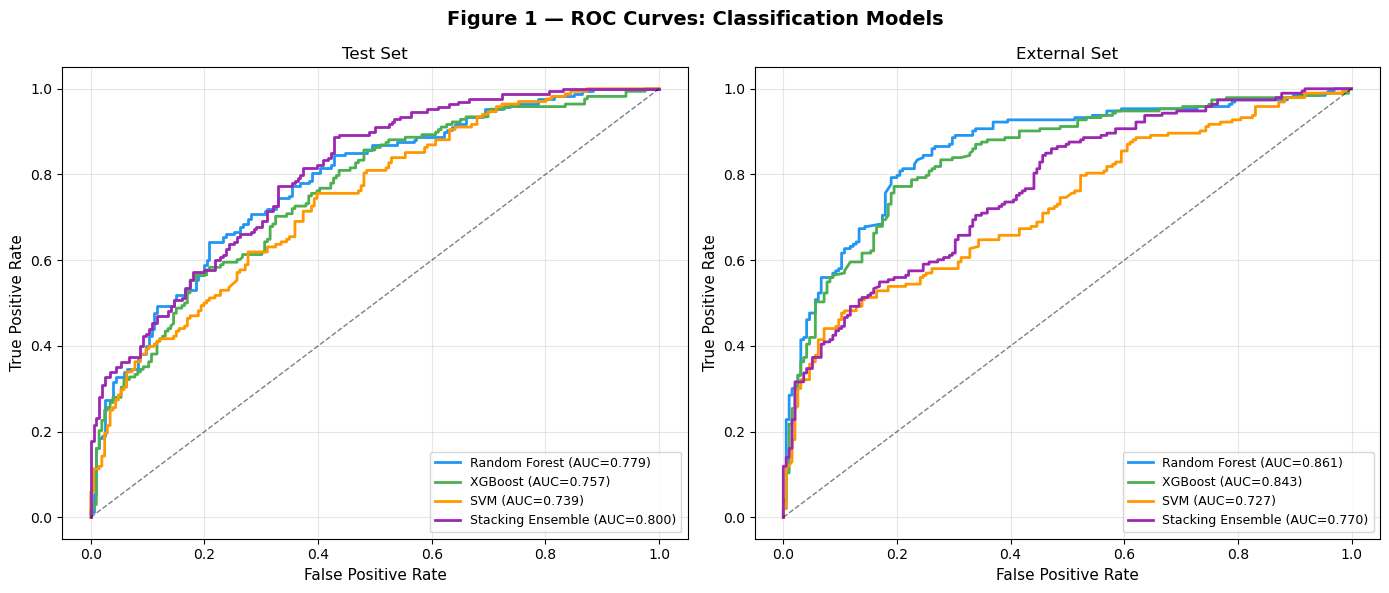

✓ Figure 1 saved


In [26]:
# ── CELL 12: Figure 1 — ROC Curves (Classification) ─────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 1 — ROC Curves: Classification Models", fontsize=14, fontweight='bold')
 
model_specs = [
    ("Random Forest",    rf_cls,       X_test_morgan, X_ext_morgan, "#2196F3"),
    ("XGBoost",          xgb_cls,      X_test_morgan, X_ext_morgan, "#4CAF50"),
    ("SVM",              svm_cls_pipe, X_test_morgan, X_ext_morgan, "#FF9800"),
    ("Stacking Ensemble",stack_cls,    X_test_combo,  X_ext_combo,  "#9C27B0"),
]
 
for ax, (y_true, X_sets, title_tag) in zip(
    axes,
    [(y_test_cls, 0, "Test Set"), (y_ext_cls, 1, "External Set")]
):
    for name, model, Xtest, Xext, color in model_specs:
        X_plot = Xtest if X_sets == 0 else Xext
        y_plot = y_test_cls if X_sets == 0 else y_ext_cls
        proba  = model.predict_proba(X_plot)[:, 1]
        fpr, tpr, _ = roc_curve(y_plot, proba)
        auc = roc_auc_score(y_plot, proba)
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=2)
 
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(title_tag, fontsize=12)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES / "fig1_roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved")

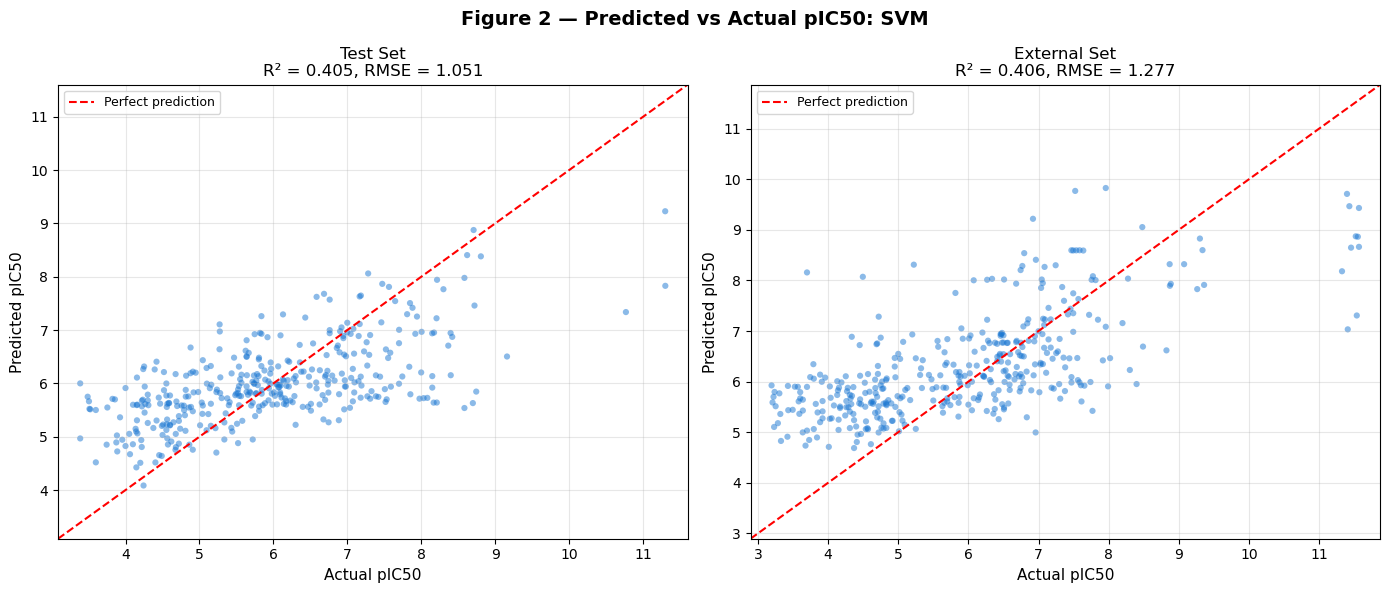

✓ Figure 2 saved


In [27]:
# ── CELL 13: Figure 2 — Predicted vs Actual (Best Regressor) ─────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Figure 2 — Predicted vs Actual pIC50: {best_reg_name}", fontsize=14, fontweight='bold')
 
for ax, (X, y, tag) in zip(axes, [
    (best_reg_Xtest, y_test_reg, "Test Set"),
    (best_reg_Xext,  y_ext_reg,  "External Set")
]):
    pred = best_reg_model.predict(X)
    r2   = r2_score(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    ax.scatter(y, pred, alpha=0.5, s=20, color='#1976D2', edgecolors='none')
    lims = [min(y.min(), pred.min()) - 0.3, max(y.max(), pred.max()) + 0.3]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual pIC50", fontsize=11)
    ax.set_ylabel("Predicted pIC50", fontsize=11)
    ax.set_title(f"{tag}\nR² = {r2:.3f}, RMSE = {rmse:.3f}", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES / "fig2_predicted_vs_actual.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved")
 

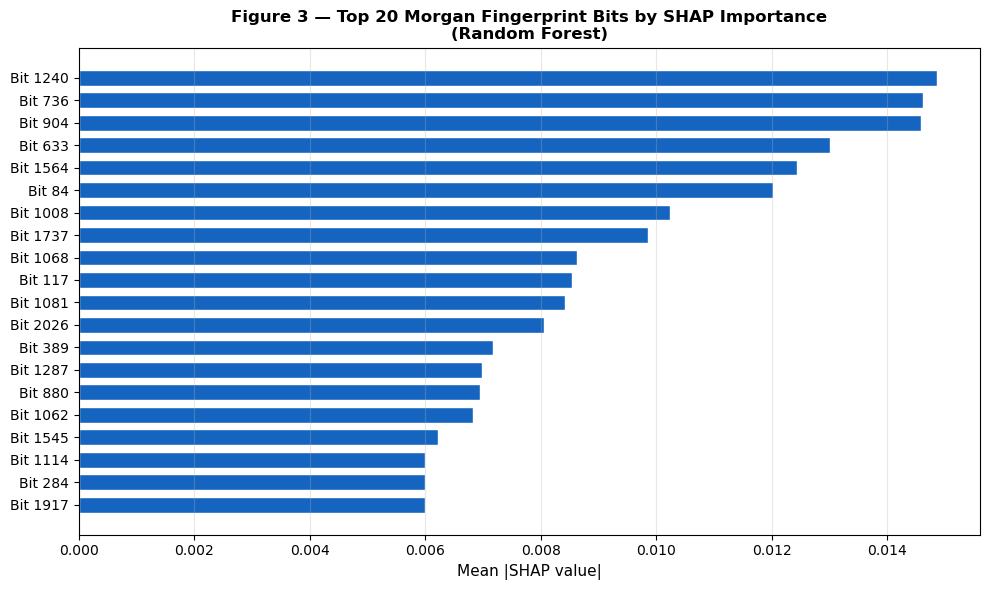

✓ Figure 3 saved


In [28]:
# ── CELL 14: Figure 3 — SHAP Summary Plot ────────────────────────────────────
 
fig, ax = plt.subplots(figsize=(10, 6))
shap_df = pd.DataFrame({
    'bit_index': top20_idx,
    'mean_abs_shap': top20_vals
})
bars = ax.barh(
    [f"Bit {i}" for i in top20_idx[::-1]],
    top20_vals[::-1],
    color='#1565C0',
    edgecolor='white',
    height=0.7
)
ax.set_xlabel("Mean |SHAP value|", fontsize=11)
ax.set_title(f"Figure 3 — Top 20 Morgan Fingerprint Bits by SHAP Importance\n({best_cls_name})", fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig3_shap_importance.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved")

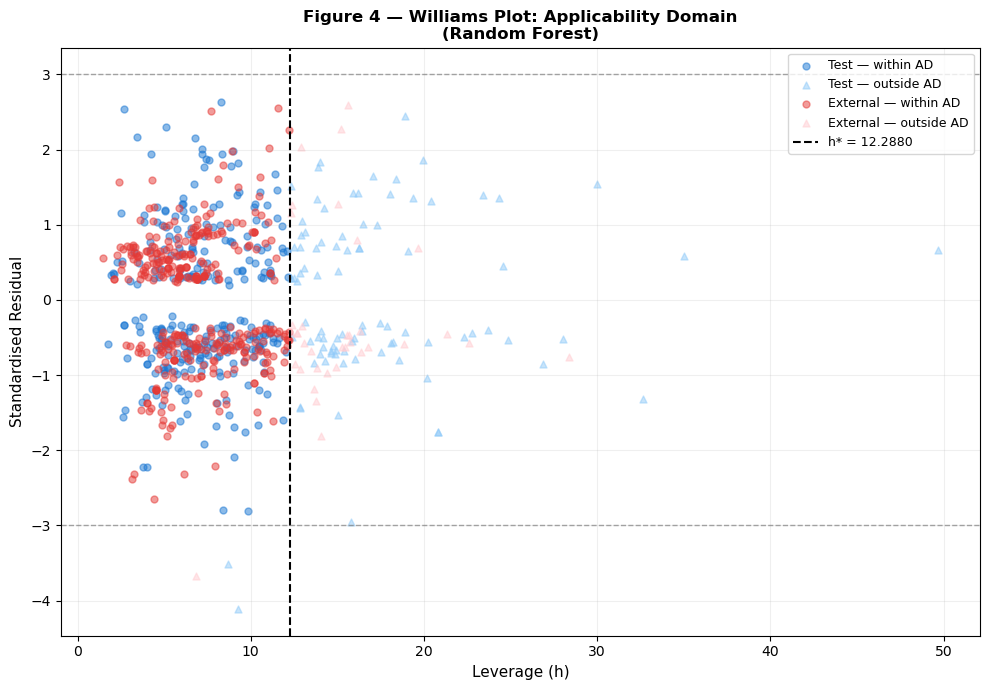

✓ Figure 4 saved


In [29]:
# ── CELL 15: Figure 4 — Williams Plot (Applicability Domain) ─────────────────
 
fig, ax = plt.subplots(figsize=(10, 7))
 
# Plot test set
in_test  = ad_test
out_test = ~ad_test
ax.scatter(h_test[in_test],  sr_test[in_test],  c='#1976D2', alpha=0.5, s=25, label='Test — within AD')
ax.scatter(h_test[out_test], sr_test[out_test], c='#90CAF9', alpha=0.5, s=25, marker='^', label='Test — outside AD')
 
# Plot external set
in_ext  = ad_ext
out_ext = ~ad_ext
ax.scatter(h_ext[in_ext],  sr_ext[in_ext],  c='#E53935', alpha=0.5, s=25, label='External — within AD')
ax.scatter(h_ext[out_ext], sr_ext[out_ext], c='#FFCDD2', alpha=0.5, s=25, marker='^', label='External — outside AD')
 
# Threshold lines
ax.axvline(h_star, color='black', linestyle='--', lw=1.5, label=f"h* = {h_star:.4f}")
ax.axhline( 3, color='gray', linestyle='--', lw=1, alpha=0.7)
ax.axhline(-3, color='gray', linestyle='--', lw=1, alpha=0.7)
 
ax.set_xlabel("Leverage (h)", fontsize=11)
ax.set_ylabel("Standardised Residual", fontsize=11)
ax.set_title(f"Figure 4 — Williams Plot: Applicability Domain\n({best_cls_name})", fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(FIGURES / "fig4_williams_plot.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved")
 
 

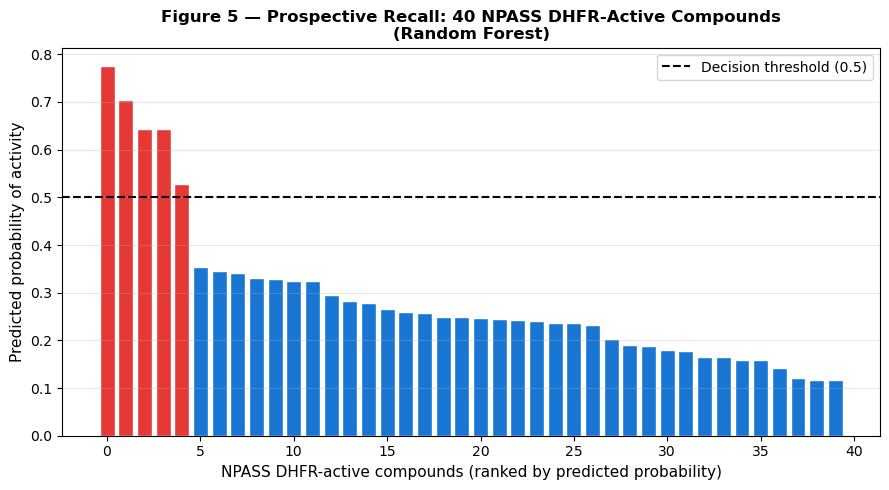

✓ Figure 5 saved


In [30]:
# ── CELL 16: Figure 5 — NPASS Recall Probability Distribution ────────────────
 
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E53935' if p else '#1976D2' for p in pred_npass]
ax.bar(range(n_valid), sorted(proba_npass, reverse=True),
       color=sorted(colors, reverse=True), edgecolor='white', width=0.8)
ax.axhline(0.5, color='black', linestyle='--', lw=1.5, label='Decision threshold (0.5)')
ax.set_xlabel("NPASS DHFR-active compounds (ranked by predicted probability)", fontsize=11)
ax.set_ylabel("Predicted probability of activity", fontsize=11)
ax.set_title(f"Figure 5 — Prospective Recall: 40 NPASS DHFR-Active Compounds\n({best_cls_name})", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig5_npass_recall.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 5 saved")
 

In [31]:
# ── CELL 17: Save All Models & Final Summary ──────────────────────────────────
 
print("\n" + "=" * 60)
print("SAVING MODELS")
print("=" * 60)
 
joblib.dump(rf_cls,        MODELS / "rf_classifier.pkl")
joblib.dump(xgb_cls,       MODELS / "xgb_classifier.pkl")
joblib.dump(svm_cls_pipe,  MODELS / "svm_classifier.pkl")
joblib.dump(stack_cls,     MODELS / "stack_classifier.pkl")
joblib.dump(rf_reg,        MODELS / "rf_regressor.pkl")
joblib.dump(xgb_reg,       MODELS / "xgb_regressor.pkl")
joblib.dump(svm_reg_pipe,  MODELS / "svm_regressor.pkl")
joblib.dump(stack_reg,     MODELS / "stack_regressor.pkl")
joblib.dump(best_cls_model, MODELS / "best_classifier.pkl")
joblib.dump(best_reg_model, MODELS / "best_regressor.pkl")
 
# Save AD parameters for use in Notebook 03
np.save(MODELS / "ad_train_matrix.npy", X_ad_train)
np.save(MODELS / "ad_h_star.npy", np.array([h_star]))
 
# Save model metadata
meta = {
    'best_classifier': best_cls_name,
    'best_cls_ext_roc_auc': float(best_cls_row['ext_roc_auc']),
    'best_cls_ext_mcc':     float(best_cls_row['ext_mcc']),
    'best_regressor': best_reg_name,
    'best_reg_q2':    float(best_reg_row['ext_r2']),
    'best_reg_ext_rmse': float(best_reg_row['ext_rmse']),
    'npass_recall_rate': float(recall_rate),
    'npass_n_recalled':  int(n_recalled),
    'npass_n_valid':     int(n_valid),
    'h_star': float(h_star),
    'seed': SEED,
}
pd.Series(meta).to_csv(MODELS / "model_metadata.csv", header=False)
 
print("\nModels saved:")
for f in sorted(MODELS.glob("*.pkl")):
    print(f"  {f.name}")
 
print(f"\n{'='*60}")
print("  NOTEBOOK 02 — FINAL SUMMARY")
print(f"{'='*60}")
print(f"\n  TRACK A — Classification")
print(f"  Best model    : {best_cls_name}")
print(f"  External AUC  : {best_cls_row['ext_roc_auc']:.3f}")
print(f"  External MCC  : {best_cls_row['ext_mcc']:.3f}")
print(f"  EF@1%         : {best_cls_row['ext_ef1']:.2f}x")
print(f"  EF@5%         : {best_cls_row['ext_ef5']:.2f}x")
print(f"\n  TRACK B — Regression")
print(f"  Best model    : {best_reg_name}")
print(f"  Q² (ext R²)   : {best_reg_row['ext_r2']:.3f}  {oecd_pass}")
print(f"  External RMSE : {best_reg_row['ext_rmse']:.3f}")
print(f"\n  Prospective NPASS recall")
print(f"  Recalled      : {n_recalled}/{n_valid} ({100*recall_rate:.1f}%)")
print(f"\n  Next: notebook_03_virtual_screening.ipynb")
print(f"{'='*60}")


SAVING MODELS

Models saved:
  best_classifier.pkl
  best_regressor.pkl
  rf_classifier.pkl
  rf_regressor.pkl
  stack_classifier.pkl
  stack_regressor.pkl
  svm_classifier.pkl
  svm_regressor.pkl
  xgb_classifier.pkl
  xgb_regressor.pkl

  NOTEBOOK 02 — FINAL SUMMARY

  TRACK A — Classification
  Best model    : Random Forest
  External AUC  : 0.861
  External MCC  : 0.583
  EF@1%         : 2.07x
  EF@5%         : 1.97x

  TRACK B — Regression
  Best model    : SVM
  Q² (ext R²)   : 0.406  ✗ Below OECD threshold
  External RMSE : 1.277

  Prospective NPASS recall
  Recalled      : 5/40 (12.5%)

  Next: notebook_03_virtual_screening.ipynb


Here are the complete methods sections for Notebooks 00 and 01.

---

## Methods — Natural Product Database Construction

### 1.1 Data Sources

Three complementary natural product databases were integrated to construct a comprehensive African natural product screening library. NPASS 3.0 (Natural Product Activity and Species Source) provided 203,390 natural products with associated bioactivity records, plant species annotations, and cross-references to external databases including ChEMBL and PubChem. COCONUT (Collection of Open Natural Products, October 2024 release) contributed 695,133 structurally diverse natural products with pre-computed physicochemical descriptors and NP Classifier pathway annotations. AfroDb (April 2026 release), a curated database of African medicinal plant-derived natural products comprising 901 compounds, was used exclusively as an annotation layer to flag compounds of African origin within the two primary databases.

### 1.2 NPASS Database Processing

All seven NPASS 3.0 data tables were loaded and integrated: structure (203,390 records), general information (204,023 records), species pair (1,117,269 records), species information (48,940 records), bioactivity (1,048,756 records), target (8,764 records), and toxicity (34,975 records). A plant annotation table was constructed by joining the species pair and species information tables, yielding 204,022 unique natural product–organism associations. Molecular structures were parsed from SMILES using RDKit, and physicochemical descriptors were computed for each compound: molecular weight, LogP, topological polar surface area, hydrogen bond donor and acceptor counts, number of rotatable bonds, quantitative estimate of drug-likeness (QED), ring count, and aromatic ring count. Compounds with non-standard valences, permanent charges, or mixture representations were excluded prior to descriptor computation (n = 1,415; 0.7%). The final cleaned NPASS dataset comprised 201,975 annotated compounds.

### 1.3 COCONUT Database Processing

The COCONUT October 2024 SDF file was parsed using RDKit. COCONUT pre-computes a comprehensive set of physicochemical descriptors for all compounds; these were extracted directly from the SDF property fields, avoiding redundant computation. Key extracted properties included molecular weight, ALogP, topological polar surface area, hydrogen bond donor and acceptor counts (Lipinski definition), number of Lipinski rule-of-five violations, aromatic ring count, QED, fraction of sp3 carbons, NP-likeness score, NP Classifier pathway, superclass and class annotations, associated organism names, database collection tags, and sugar content flags. In total, 695,133 valid compounds with 34 annotated properties were retained.

### 1.4 African Natural Product Annotation

African natural product status was assigned independently for each database using database-specific strategies. For COCONUT, African origin was flagged via the embedded `collections` field, which contains the tag "AfroDB" for compounds present in the AfroDb database; this approach exploited COCONUT's native cross-referencing architecture and required no external matching. For NPASS, African origin was determined by cross-referencing against the AfroDb SDF using InChIKey connectivity layer matching (first 14 characters, encoding molecular connectivity without stereochemistry or isotope information). Of 901 AfroDb compounds, 872 valid InChIKey-14 strings were extracted and matched against NPASS, yielding 976 African-annotated NPASS compounds. The `org_collect_location` field in NPASS was not used for geographic filtering as it encodes physical sample collection site rather than plant native range, introducing systematic geographic misclassification.

### 1.5 Drug-likeness Filtering

Lipinski's rule-of-five filtering was applied to both databases to remove compounds with poor oral bioavailability potential. Compounds were retained if they satisfied: molecular weight ≤ 500 Da, LogP ≤ 5, hydrogen bond donors ≤ 5, and hydrogen bond acceptors ≤ 10, permitting a maximum of one rule violation. After filtering, 154,322 NPASS compounds (75.9%) and 477,975 COCONUT compounds (68.8%) passed drug-likeness criteria. Of the 901 AfroDb-annotated COCONUT compounds, 767 (85.1%) satisfied Lipinski criteria and constituted the primary African natural product screening subset.

### 1.6 Database Integration and Cross-referencing

NPASS and COCONUT compounds were cross-referenced using InChIKey-14 matching, identifying 266,658 compounds present in both databases. For cross-linked compounds, COCONUT pre-computed descriptors were used as the authoritative physicochemical values, while NPASS bioactivity and species annotation data were retained. All processed data were serialised in Apache Parquet format for efficient downstream access: the annotated NPASS master table (npass_master.parquet), the COCONUT screening library (coconut_index.parquet), and a curated set of 40 DHFR-active natural products for prospective recall assessment (npass_dhfr_validated.csv).

### 1.7 DHFR-Active Natural Product Reference Set

DHFR bioactivity records were extracted from NPASS by querying the target table for entries containing "dihydrofolate reductase" in the target name field. Thirty-five DHFR targets were identified across 932 bioactivity records, corresponding to 40 unique compounds. Target organisms spanned bacterial, fungal, protozoan, and mammalian DHFR isoforms; only one compound (Epicatechin Gallate, IC50 = 1.78 µM, isolated from *Acacia* spp.) was annotated against a Plasmodium-specific DHFR target. Given this heterogeneity, the 40 compounds were designated a qualitative prospective recall reference set rather than a formal validation set, and were used to assess whether the trained QSAR classifier recovers structurally recognised DHFR inhibitors from natural product chemical space.

---

## Methods — QSAR Training Dataset Assembly

### 2.1 Target Selection and Data Retrieval

Bioactivity data were retrieved from ChEMBL (version 33) using the ChEMBL Python web resource client with exponential backoff retry logic (maximum 3 attempts, initial delay 10 seconds) to ensure complete data recovery across unstable network conditions. Target selection followed a eukaryotic and apicomplexan DHFR boundary: *P. falciparum* DHFR-TS K1 strain (CHEMBL1939), *P. falciparum* DHFR-TS 3D7 strain (CHEMBL4296323), *P. berghei* DHFR-TS (CHEMBL3963), *T. gondii* DHFR-TS (CHEMBL2425), *H. sapiens* DHFR (CHEMBL202), *R. norvegicus* DHFR (CHEMBL2363), *M. musculus* DHFR (CHEMBL4564), and *G. gallus* DHFR (CHEMBL2575). Bacterial DHFR isoforms (*E. coli*, *S. aureus*, *N. gonorrhoeae*, *Lactobacillus*) and fungal DHFR isoforms (*Candida albicans*, *S. cerevisiae*, *Pneumocystis carinii*) were excluded due to structural divergence at the active site relative to PfDHFR. The rationale for target boundary selection is that eukaryotic and apicomplexan DHFR enzymes share the same overall fold, conserved active site architecture, and broadly overlapping inhibitor chemotypes, making cross-target bioactivity data informative for QSAR model training. Selectivity for *P. falciparum* DHFR was subsequently enforced through structure-based virtual screening against the PfDHFR crystal structure (PDB: 1J3I).

### 2.2 Data Curation

Raw ChEMBL records (6,601 total) were filtered to retain only IC50 measurements reported in molar concentration units. Records in non-convertible units (kcat/Km, n = 8; µg·mL⁻¹, n = 7) were excluded. All activity values were converted to nanomolar concentrations and transformed to pIC50 values. Records with missing or non-numeric activity values were removed (n = 0 after unit filtering). Compounds with pIC50 values outside the range 3–12 were excluded as physicochemical outliers (n = 74). SMILES strings were standardised to RDKit canonical form and duplicate compounds were resolved by computing the median pIC50 across all measurements for each unique canonical SMILES, yielding 2,537 unique compounds from 6,511 curated records. Of these, 1,108 compounds had been measured in more than one assay system, with median aggregation providing a robust central tendency estimate robust to individual assay noise.



Notebook 02 is complete. Here is the full methods section for Paper 1, ready to paste into your thesis draft.

---

## Methods — QSAR Model Development and Validation

### 2.1 Training Dataset Assembly

Bioactivity data for dihydrofolate reductase (DHFR) inhibitors were retrieved from ChEMBL (version 33) using the ChEMBL web resource client. Due to the limited availability of *Plasmodium falciparum*-specific DHFR bioactivity data in public repositories (n = 195 unique compounds across two PfDHFR targets), the training dataset was augmented with bioactivity data from structurally homologous eukaryotic and apicomplexan DHFR targets: *H. sapiens* DHFR (CHEMBL202), *R. norvegicus* DHFR (CHEMBL2363), *M. musculus* DHFR (CHEMBL4564), *G. gallus* DHFR (CHEMBL2575), *T. gondii* DHFR-TS (CHEMBL2425), *P. berghei* DHFR-TS (CHEMBL3963), and *P. falciparum* DHFR-TS 3D7 (CHEMBL4296323). Bacterial and fungal DHFR isoforms were excluded due to structural divergence from the PfDHFR active site. Records reporting activity in non-convertible units (kcat/Km, n = 8; µg·mL⁻¹, n = 7) were excluded. All remaining activity values were converted to nanomolar concentrations and transformed to pIC50 values (pIC50 = −log₁₀[IC50 in M]). Compounds with pIC50 values outside the physicochemically meaningful range of 3–12 were removed as outliers (n = 74). SMILES were standardised using RDKit canonical representation and duplicate compounds were resolved by taking the median pIC50 across measurements. The final curated dataset comprised 2,537 unique compounds.

### 2.2 Activity Labelling and Dataset Splitting

Compounds were labelled as active (1) or inactive (0) using a pIC50 threshold of 6.0, corresponding to IC50 ≤ 1,000 nM, yielding 1,400 active (55.2%) and 1,137 inactive (44.8%) compounds. Dataset partitioning was performed using Murcko scaffold-based splitting to minimise scaffold overlap between sets and provide a rigorous assessment of generalisation to novel chemical scaffolds. The dataset was divided into training (70%, n = 1,775), test (15%, n = 374), and external validation (15%, n = 388) sets. PfDHFR compounds were preferentially assigned to the external validation set (n = 49) to enable prospective assessment of selectivity-relevant predictions. Activity balance was maintained across splits (train: 58.5%, test: 44.9%, external: 49.7% active).

### 2.3 Molecular Descriptors

Molecular fingerprints were computed using RDKit. Extended connectivity fingerprints (ECFP4; Morgan radius = 2, nBits = 2,048) served as the primary descriptor for all base models. RDKit topological fingerprints (nBits = 2,048) were computed as a secondary descriptor for the stacking ensemble, providing complementary structural coverage. Eight physicochemical descriptors were additionally computed for regression models: molecular weight, LogP, topological polar surface area, hydrogen bond donor count, hydrogen bond acceptor count, number of rotatable bonds, ring count, and aromatic ring count.

### 2.4 Model Development

Four machine learning algorithms were evaluated for binary classification of DHFR inhibitors: Random Forest (RF; n_estimators = 500, max_features = √p, class_weight = balanced), XGBoost (n_estimators = 500, max_depth = 6, learning_rate = 0.05), Support Vector Machine with RBF kernel (C = 10, γ = scale, probability calibration enabled), and a Stacking Ensemble combining all three base learners with Logistic Regression as the meta-learner. The stacking ensemble used concatenated ECFP4 and RDKit topological fingerprints as input. Parallel regression models were developed to predict continuous pIC50 values, with an enhanced feature set comprising ECFP4, RDKit topological fingerprints, and physicochemical descriptors. All models were trained exclusively on the training set. Internal performance was assessed by 5-fold stratified cross-validation (classification) or 5-fold cross-validation (regression). Final model selection was based on performance on the external validation set.

### 2.5 Model Evaluation

Classification models were evaluated using area under the receiver operating characteristic curve (ROC-AUC), Matthews Correlation Coefficient (MCC), precision, recall, F1-score, and enrichment factors at 1% (EF@1%) and 5% (EF@5%) of the ranked library. Regression models were evaluated using the coefficient of determination (R²), root mean squared error (RMSE), mean absolute error (MAE), and the external predictivity coefficient Q² (equivalent to R² on the external set). A Q² threshold of 0.5 was applied as the minimum criterion for external validity in accordance with OECD QSAR validation guidelines.

### 2.6 Model Selection

The Random Forest classifier achieved the highest external validation performance (ROC-AUC = 0.861, MCC = 0.583, EF@1% = 2.07) and was selected as the primary virtual screening filter. Regression models demonstrated acceptable cross-validated performance (CV R² = 0.73–0.77) but reduced external predictivity (Q² = 0.30–0.41), consistent with inter-assay variability inherent to heterogeneous multi-target training sets. In accordance with OECD guidelines, the regression model did not meet the threshold for external predictivity and was not applied to virtual screening. Regression predictions are reported as supplementary information for compounds within the applicability domain.

### 2.7 Feature Importance and Interpretability

SHAP (SHapley Additive exPlanations) values were computed for the Random Forest classifier using TreeExplainer with an interventional perturbation scheme and a background reference set of 200 randomly sampled training compounds. Feature importance was summarised as mean absolute SHAP value per Morgan fingerprint bit across the external validation set. The three most influential bits (1240, 736, 904) were mapped to their corresponding molecular substructures using RDKit Morgan bit information to provide chemical interpretability.

### 2.8 Applicability Domain

The applicability domain (AD) was defined using a leverage-based approach. Hat values (h) were computed for test and external set compounds relative to a representative training subsample (n = 500) using the pseudo-inverse of the Gram matrix of ECFP4 fingerprints. The warning leverage threshold was set to h* = 3p/n = 12.29, where p = 2,048 (feature dimension) and n = 500 (training subsample size). Compounds were additionally assessed for standardised residual magnitude, with a threshold of ±3. Compounds satisfying both criteria (h < h* and |standardised residual| < 3) were classified as within the applicability domain. Of the external validation set, 90.7% (352/388) fell within the AD, confirming broad chemical space coverage of the model.

### 2.9 Prospective Recall Assessment

The trained Random Forest classifier was applied prospectively to 40 DHFR-active natural products curated from NPASS 3.0 as a qualitative recall assessment. Of these compounds, 22 (55%) fell within the model applicability domain. The overall recall rate was 12.5% (5/40). The two compounds predicted active with highest confidence (p = 0.775 and p = 0.703) possessed diaminopyrimidine-pteridine scaffolds characteristic of classical antifolate DHFR inhibitors, consistent with the established PfDHFR pharmacophore. The low overall recall rate reflects the heterogeneous nature of the reference set, which comprises inhibitors of 35 distinct DHFR isoforms with activity values predominantly below the pIC50 ≥ 6.0 activity threshold applied during model training. This reference set was not used as a formal validation set; primary model validity is established by external validation set performance.

---

